In [2]:
# importation bibliotheques
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integr

Matplotlib is building the font cache; this may take a moment.


In [3]:
# on utilise graine aléatoire pour la reproductibilité des résultats
np.random.seed(0)

In [4]:
#PARTIE A 
#creation x avec 600 points entre -3 et 3
x = np.linspace(-3, 3, 600)

In [12]:
# I.2 Dictionnaire des fonctions d'activation
# Définir les dictionnaires "activations" et "d_activations"

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_stable(x):
    return np.where(
        x >= 0,
        1 / (1 + np.exp(-x)),
        np.exp(x) / (1 + np.exp(x))
    )

def tanh_fn(x):
    return np.tanh(x)

def leaky_relu(x, a=0.1):
    return np.where(x > 0, x, a * x)


activations = {
    "Relu":           relu(x),
    "Sigmoid":        sigmoid(x),
    "Sigmoid_stable": sigmoid_stable(x),
    "Tanh":           tanh_fn(x),
    "LeakyRelu":      leaky_relu(x),
}

# --- Dérivées ---
d_activations = {
    "Relu":           lambda z:    (z > 0).astype(float),
    "Sigmoid":        lambda out:  out * (1 - out),
    "Sigmoid_stable": lambda out:  out * (1 - out),
    "Tanh":           lambda out:  1 - out**2,
    "LeakyRelu":      lambda z:    np.where(z > 0, 1, 0.1),
}

# I.4 Dictionnaire style des courbes (couleurs et marqueurs)

couleurs = {
    "Relu":           "tab:blue",
    "Sigmoid":        "tab:green",
    "Sigmoid_stable": "tab:purple",
    "Tanh":           "tab:red",
    "LeakyRelu":      "tab:orange",
}

markers = {
    "Relu":           "o",
    "Sigmoid":        "s",
    "Sigmoid_stable": "s",
    "Tanh":           "^",
    "LeakyRelu":      "D",
}

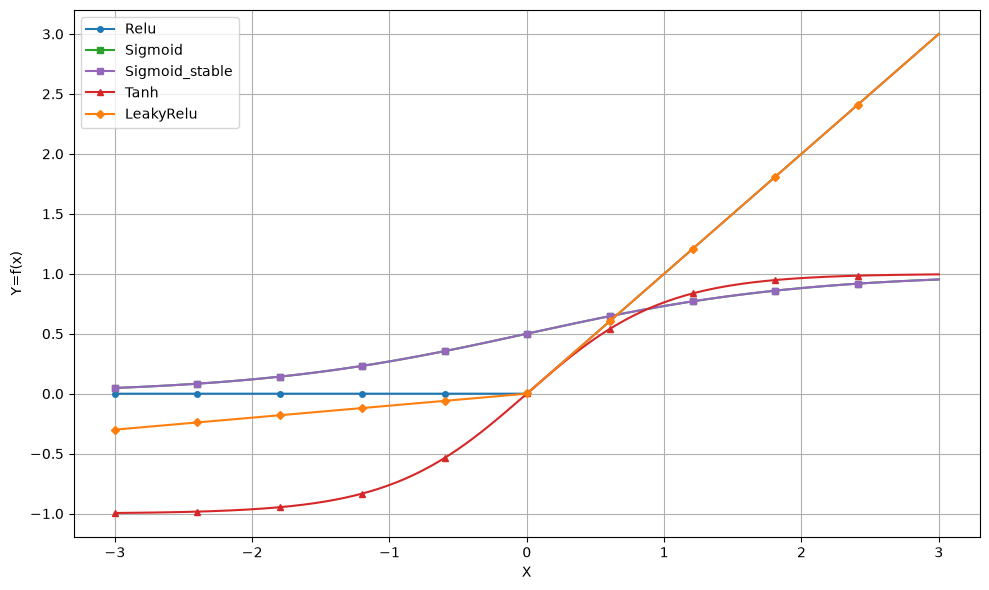

In [14]:
#Tracé comparatif
plt.figure(figsize=(10, 6))

for name, y_vals in activations.items():
    plt.plot(
        x, y_vals,
        label=name,
        color=couleurs[name],
        marker=markers[name],
        markersize=4,
        markevery=60   
    )

plt.xlabel("X")
plt.ylabel("Y=f(x)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("figures/trace_comparatif.png", dpi=150)
plt.show()


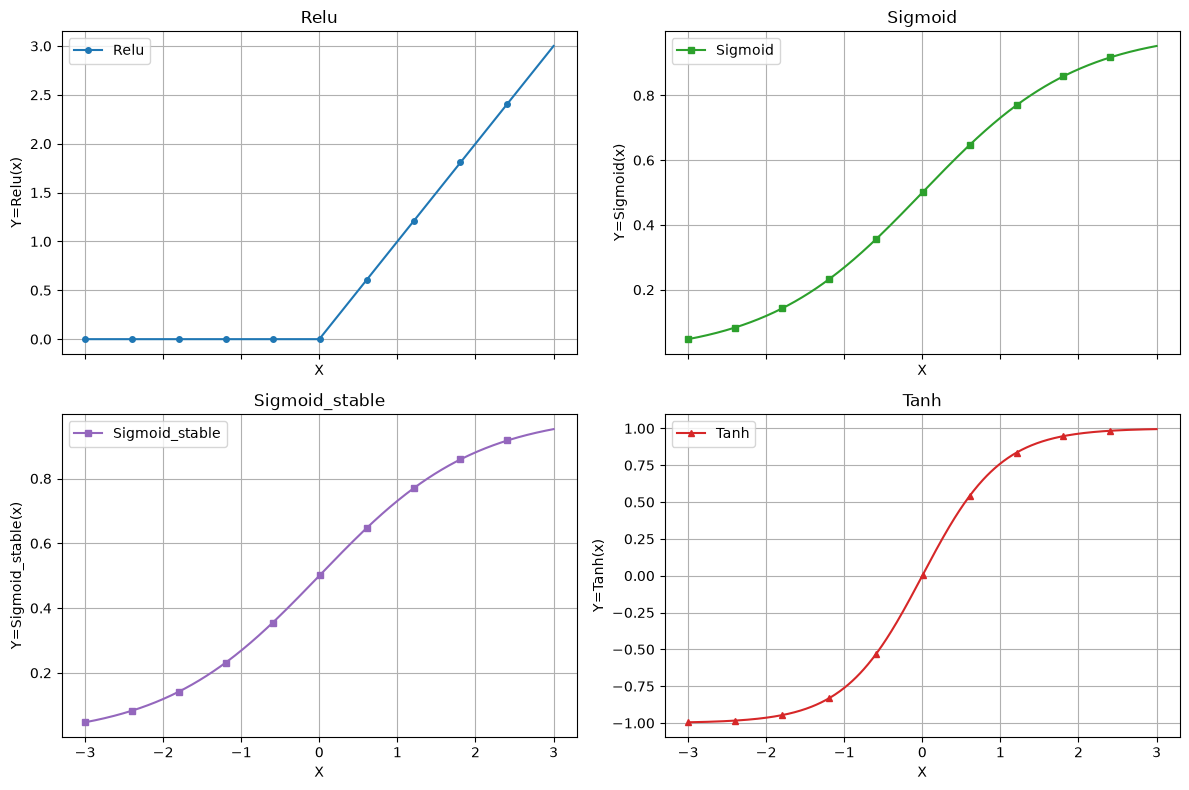

In [15]:
#subplots(2x2) pour le Tracé de chaque fonction sur une sous figure
fonctions_base = ["Relu", "Sigmoid", "Sigmoid_stable", "Tanh"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()   # aplatir en tableau 1D pour itérer facilement

for i, name in enumerate(fonctions_base):
    ax = axes[i]
    ax.plot(
        x, activations[name],
        color=couleurs[name],
        marker=markers[name],
        markersize=4,
        markevery=60,
        label=name
    )
    ax.set_title(name)
    ax.set_xlabel("X")
    ax.set_ylabel(f"Y={name}(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig("figures/subplots.png", dpi=150)
plt.show()


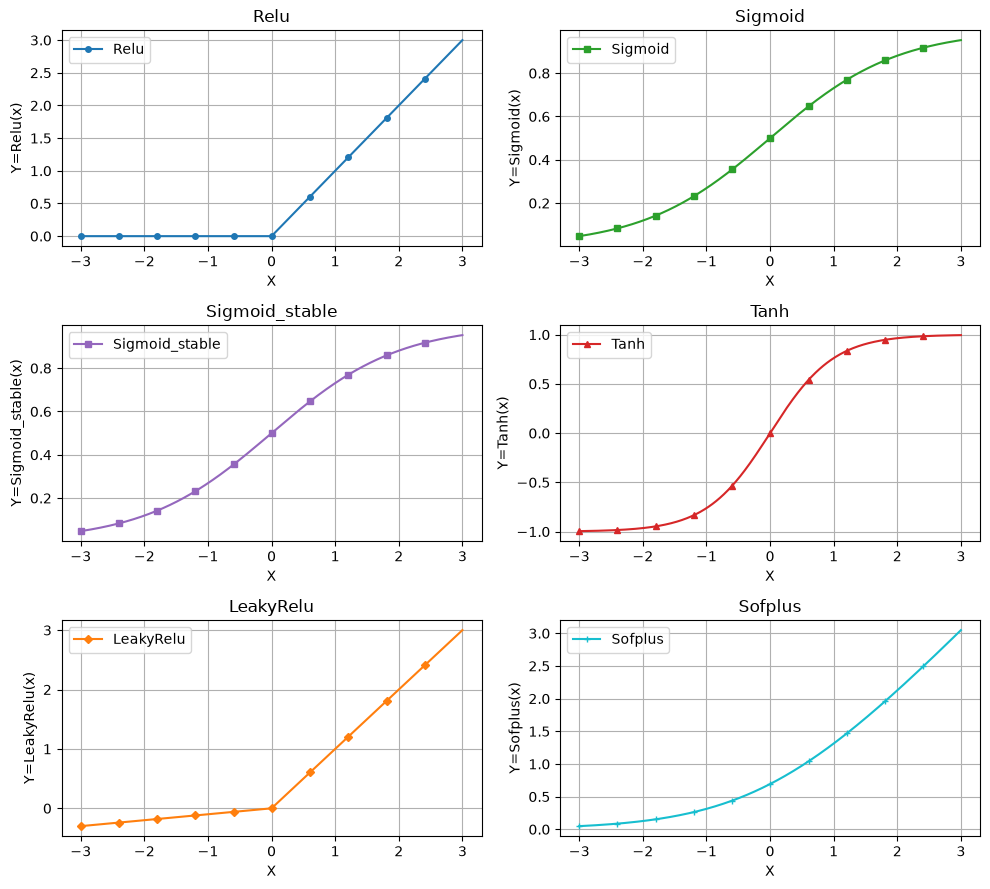

In [17]:
#Extension 1 par ajout de 2 fonctions d'activation supp
def softplus(x):
    return np.log(1 + np.exp(x))

def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

activations["Sofplus"] = softplus(x)
activations["ELU"]     = elu(x)

couleurs["Sofplus"] = "tab:cyan"
couleurs["ELU"]     = "tab:pink"

markers["Sofplus"] = "+"
markers["ELU"]     = "x"

def sub_tracer(rows, cols):
    keys = list(activations.keys())[:rows * cols]
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3))
    axes = axes.ravel()
    for i, name in enumerate(keys):
        axes[i].plot(
            x, activations[name],
            color=couleurs[name],
            marker=markers[name],
            markersize=4,
            markevery=60,
            label=name
        )
        axes[i].set_title(name)
        axes[i].set_xlabel("X")
        axes[i].set_ylabel(f"Y={name}(x)")
        axes[i].grid(True)
        axes[i].legend()
    plt.tight_layout()
    plt.savefig(f"figures/subplots_{rows}x{cols}.png", dpi=150)
    plt.show()

sub_tracer(3, 2)


In [20]:
#Extension 2 : implementation
# V2 préparer le mini dataset de fonction XOR
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)             

y = np.array([[0], [1], [1], [0]], dtype=float)  

print(X.shape)  
print(y.shape)  

(4, 2)
(4, 1)


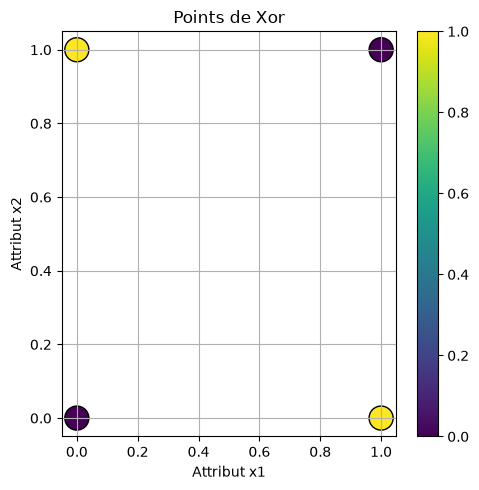

In [22]:
#V3 Visualiser les ponits XOR
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap="viridis", s=300, edgecolors="k")
plt.colorbar()
plt.title("Points de Xor")
plt.xlabel("Attribut x1")
plt.ylabel("Attribut x2")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/figure_points_xor.png", dpi=150)
plt.show()


In [23]:
#V4 Initialisation des paramètres : W1,b1,W2,b2
np.random.seed(0)   
W1 = np.random.randn(2, 3) * 0.1   
b1 = np.zeros((1, 3))
W2 = np.random.randn(3, 1) * 0.1
b2 = np.zeros((1, 1))

print(f"\nW1.shape : {W1.shape}    b1.shape : {b1.shape}")
print(f"W2.shape : {W2.shape}    b2.shape : {b2.shape}")
print(f"W1 =\n{W1}\nb1 = {b1}")
print(f"W2 =\n{W2}\nb2 = {b2}")


W1.shape : (2, 3)    b1.shape : (1, 3)
W2.shape : (3, 1)    b2.shape : (1, 1)
W1 =
[[ 0.17640523  0.04001572  0.0978738 ]
 [ 0.22408932  0.1867558  -0.09772779]]
b1 = [[0. 0. 0.]]
W2 =
[[ 0.09500884]
 [-0.01513572]
 [-0.01032189]]
b2 = [[0.]]


In [24]:
#V5 Choix des fonctions d'activation (une par couche)
act_hid   = tanh_fn       
d_act_hid = d_tanh        

act_out   = sigmoid      
d_act_out = d_sigmoid     


In [25]:
#Propagation avant (Forward pass)
def forward(X, W1, b1, W2, b2, act_hid, act_out):
    # Couche 1
    Z1 = X @ W1 + b1          
    A1 = act_hid(Z1)           

    # Couche 2
    Z2 = A1 @ W2 + b2         
    y_hat = act_out(Z2)   

    cache = (X, Z1, A1, Z2, y_hat)
    return y_hat, cache

y_hat, cache = forward(X, W1, b1, W2, b2, act_hid, act_out)
print(f"\ny_hat :\n{y_hat}")
print(f"y_hat shape: {y_hat.shape}") 


y_hat :
[[0.5       ]
 [0.50478795]
 [0.50374392]
 [0.50818989]]
y_hat shape: (4, 1)


In [28]:
#V7 : Fonction de perte (L) (MSE)
def mse(y_hat, y):
    N = y.shape[0]
    return (1 / N) * np.sum((y_hat - y) ** 2)

print(f"Loss: {mse(y_hat, y)}")

Loss: 0.24994050979791232


In [32]:
#V9 boucle d'entrainement (Gradient descent)
def train(X, y, W1, b1, W2, b2, lr=0.8, epochs=2000,
          f_act_hid=tanh_fn, f_act_out=sigmoid,
          df_hid=d_tanh, df_out=d_sigmoid):
          
    losses = []
    for epoch in range(epochs):

        # --------- Forward ---------
        y_hat, (Xc, Z1, A1, Z2, yhc) = forward(
            X, W1, b1, W2, b2, f_act_hid, f_act_out)

        # --------- Loss ---------
        L = mse(y_hat, y)
        losses.append(L)

        # --------- Backprop ---------
        N = y.shape[0]

        # Étape 1 
        dY = (2 / N) * (y_hat - y)          

        # Étape 2 (dérivée sigmoid par rapport à la sortie)
        dZ2 = dY * df_out(y_hat)           

        # Étape 3 : gradients W2, b2
        dW2 = A1.T @ dZ2                    
        db2 = np.sum(dZ2, axis=0, keepdims=True)  

        # Étape 4 : propager vers la couche cachée
        dA1 = dZ2 @ W2.T                  
        dZ1 = dA1 * df_hid(A1)             

        # Étape 5 : gradients W1, b1
        dW1 = Xc.T @ dZ1                    
        db1 = np.sum(dZ1, axis=0, keepdims=True) 

        # --------- Mise à jour ---------
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 400 == 0:
            print(f"epoch={epoch:4d}  loss={L:.6f}")

    return W1, b1, W2, b2, losses


# Entraîner sur XOR pur 
W1t, b1t, W2t, b2t, losses = train(
    X, y, W1.copy(), b1.copy(), W2.copy(), b2.copy(),
    lr=0.8, epochs=4000,
    f_act_hid=act_hid, f_act_out=act_out,
    df_hid=d_act_hid,  df_out=d_act_out
)

y_pred, _ = forward(X, W1t, b1t, W2t, b2t, act_hid, act_out)
print(f"\nProbas:\n{y_pred}")
print(f"\nClasses (seuil 0.5):\n{(y_pred >= 0.5).astype(int)}")


epoch=   0  loss=0.249941
epoch= 400  loss=0.040898
epoch= 800  loss=0.002775
epoch=1200  loss=0.001282
epoch=1600  loss=0.000818
epoch=2000  loss=0.000596
epoch=2400  loss=0.000467
epoch=2800  loss=0.000383
epoch=3200  loss=0.000324
epoch=3600  loss=0.000281

Probas:
[[0.0163467 ]
 [0.98819864]
 [0.98363113]
 [0.01775057]]

Classes (seuil 0.5):
[[0]
 [1]
 [1]
 [0]]


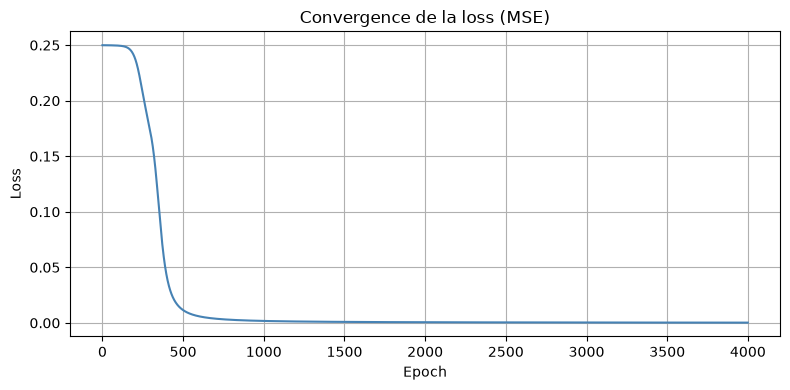

In [33]:
#V10 : Courbe de convergence de la loss
plt.figure(figsize=(8, 4))
plt.plot(losses, color="steelblue")
plt.title("Convergence de la loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/convergence.png", dpi=150)
plt.show()

In [34]:
# PARTIE B : Dataset bruité + Évaluation du modèle
# Génération du dataset XOR bruité
def make_noisy_xor(n=50, noise=0.08, flip=0.05, seed=0):
    """
    Génère un dataset XOR bruité.

    Paramètres
    ----------
    n     : exemples par coin (total = 4*n)
    noise : écart-type du bruit gaussien sur les features
    flip  : probabilité d'inverser un label (0→1 ou 1→0)
    seed  : graine aléatoire

    Retourne
    --------
    x : (4*n, 2)  — features bruitées
    y : (4*n, 1)  — labels éventuellement inversés
    """
    rng = np.random.default_rng(seed)

    # 4 coins XOR de base
    coins  = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
    labels = np.array([[0],    [1],    [1],    [0]],    dtype=float)

    # Dupliquer n fois chaque coin
    x = np.repeat(coins,  n, axis=0)   
    y = np.repeat(labels, n, axis=0)   

    # Ajouter du bruit gaussien sur les features
    x += rng.normal(0, noise, x.shape)

    # Inverser aléatoirement des labels
    mask = rng.random(len(y)) < flip
    y[mask] = 1 - y[mask]

    return x, y




In [35]:
# Générer le dataset 
X, y = make_noisy_xor(n=100, noise=0.05, flip=0.04)
print(x.shape)
print(np.hstack([X,y]))

(600,)
[[ 0.00628651 -0.00660524  0.        ]
 [ 0.03202113  0.00524501  0.        ]
 [-0.02678347  0.01807975  0.        ]
 ...
 [ 1.03941036  0.9459124   0.        ]
 [ 0.97487167  0.94809679  0.        ]
 [ 0.93544857  1.00509314  0.        ]]


In [37]:
#  Séparation Train / Test

def split_dataset(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    N   = len(X)
    indices = np.arange(N)
    rng.shuffle(indices)

    cut = int((1 - test_ratio) * N)
    train_idx = indices[:cut]
    test_idx  = indices[cut:]

    X_train = X[train_idx]
    X_test  = X[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = split_dataset(X, y)
print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}") 


Train size : (320, 2)
Test size  : (80, 2)


epoch=   0  loss=0.249617
epoch= 400  loss=0.197215
epoch= 800  loss=0.047200
epoch=1200  loss=0.040102
epoch=1600  loss=0.039141
epoch=2000  loss=0.038837
epoch=2400  loss=0.038702
epoch=2800  loss=0.038630
epoch=3200  loss=0.038586
epoch=3600  loss=0.038557
epoch=4000  loss=0.038536
epoch=4400  loss=0.038520
epoch=4800  loss=0.038508
epoch=5200  loss=0.038498
epoch=5600  loss=0.038490
epoch=6000  loss=0.038483
epoch=6400  loss=0.038477
epoch=6800  loss=0.038472
epoch=7200  loss=0.038467
epoch=7600  loss=0.038463
epoch=8000  loss=0.038459
epoch=8400  loss=0.038455
epoch=8800  loss=0.038452
epoch=9200  loss=0.038449
epoch=9600  loss=0.038446


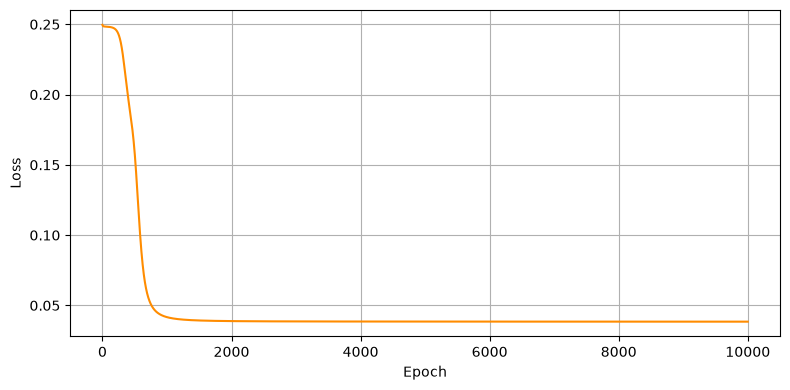

In [39]:
# Entraînement
np.random.seed(0)
W1b = np.random.randn(2, 3) * 0.1
b1b = np.zeros((1, 3))
W2b = np.random.randn(3, 1) * 0.1
b2b = np.zeros((1, 1))

W1b, b1b, W2b, b2b, losses_b = train(
    X_train, y_train,
    W1b, b1b, W2b, b2b,
    lr=0.5,
    epochs=10000,
    f_act_hid=act_hid, f_act_out=act_out,
    df_hid=d_act_hid,  df_out=d_act_out
)

# Courbe de convergence 
plt.figure(figsize=(8, 4))
plt.plot(losses_b, color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/figure_convergence_bruite.png", dpi=150)
plt.show()


In [40]:
#Predirection du model 
# conversion en classes
y_score, _ = forward(X_test, W1b, b1b, W2b, b2b, act_hid, act_out)
threshold  = 0.5
y_pred_test = (y_score >= threshold).astype(int)

print(f"Classes :\n{y_pred_test[:5]}")


Classes :
[[0]
 [1]
 [0]
 [1]
 [1]]



TP : 32
TN : 43
FP : 3
FN : 2


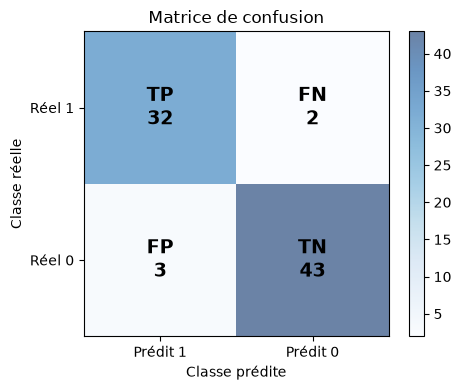

In [41]:
# Matrice de confusion

def confusion_matrix(y_true, y_pred):
    y_true = y_true.ravel().astype(int)
    y_pred = y_pred.ravel().astype(int)

    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))

    return TP, TN, FP, FN


TP, TN, FP, FN = confusion_matrix(y_test, y_pred_test)
print(f"\nTP : {TP}\nTN : {TN}\nFP : {FP}\nFN : {FN}")

# Visualiser la matrice
cm     = np.array([[TP, FN], [FP, TN]])
cm_txt = np.array([["TP\n" + str(TP), "FN\n" + str(FN)],
                   ["FP\n" + str(FP), "TN\n" + str(TN)]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", alpha=0.6)
plt.title("Matrice de confusion")
plt.colorbar()
plt.xticks([0, 1], ["Prédit 1", "Prédit 0"])
plt.yticks([0, 1], ["Réel 1",   "Réel 0"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm_txt[i, j], ha="center", va="center",
                 fontsize=14, fontweight="bold")

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.tight_layout()
plt.savefig("figures/figure_confusion_matrix.png", dpi=150)
plt.show()


In [42]:
# Métriques de classification

def classification_metrics(TP, TN, FP, FN):
    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return accuracy, precision, recall, f1


accuracy, precision, recall, f1 = classification_metrics(TP, TN, FP, FN)
print(f"\nAccuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1        : {f1:.4f}")



Accuracy  : 0.9375
Precision : 0.9143
Recall    : 0.9412
F1        : 0.9275


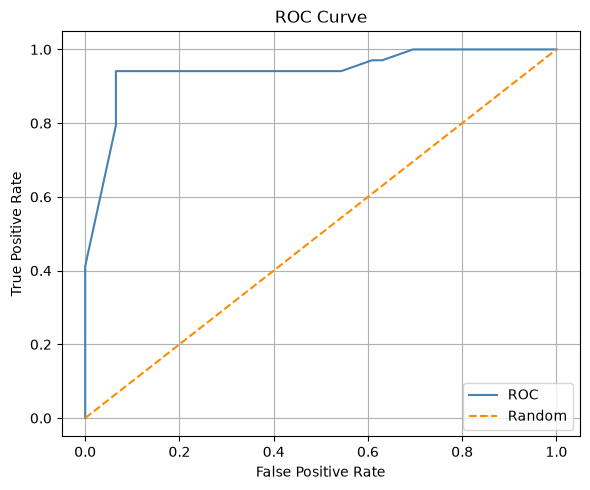

In [ ]:
#  Courbe ROC 

def roc_curve(y_true, y_score):
    
    thresholds = np.linspace(1, 0, 200)
    TPR_list = []
    FPR_list = []

    for t in thresholds:
        y_pred_t = (y_score >= t).astype(int)
        TP_t, TN_t, FP_t, FN_t = confusion_matrix(y_true, y_pred_t)

        tpr = TP_t / (TP_t + FN_t) if (TP_t + FN_t) > 0 else 0.0
        fpr = FP_t / (FP_t + TN_t) if (FP_t + TN_t) > 0 else 0.0

        TPR_list.append(tpr)
        FPR_list.append(fpr)

    return np.array(FPR_list), np.array(TPR_list)


FPR, TPR = roc_curve(y_test, y_score)

# Tracé
plt.figure(figsize=(6, 5))
plt.plot(FPR, TPR, color="steelblue", label="ROC")
plt.plot([0, 1], [0, 1], color="darkorange", linestyle="--", label="Random")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/figure_roc_curve.png", dpi=150)
plt.show()




In [44]:
# AUC
auc = integr.trapezoid(TPR, FPR)
print("AUC =",auc)

AUC = 0.9414961636828645


ANALYSE

 Influence du Learning Rate 
epoch=   0  loss=0.249841
epoch= 400  loss=0.249756
epoch= 800  loss=0.249723
epoch=1200  loss=0.249708
epoch=1600  loss=0.249699
epoch=   0  loss=0.249841
epoch= 400  loss=0.249647
epoch= 800  loss=0.249447
epoch=1200  loss=0.248659
epoch=1600  loss=0.244522
epoch=   0  loss=0.249841
epoch= 400  loss=0.227940
epoch= 800  loss=0.054733
epoch=1200  loss=0.044329
epoch=1600  loss=0.043286
epoch=   0  loss=0.249841
epoch= 400  loss=0.054925
epoch= 800  loss=0.043287
epoch=1200  loss=0.042880
epoch=1600  loss=0.042787
epoch=   0  loss=0.249841
epoch= 400  loss=0.043290
epoch= 800  loss=0.042787
epoch=1200  loss=0.042723
epoch=1600  loss=0.042695


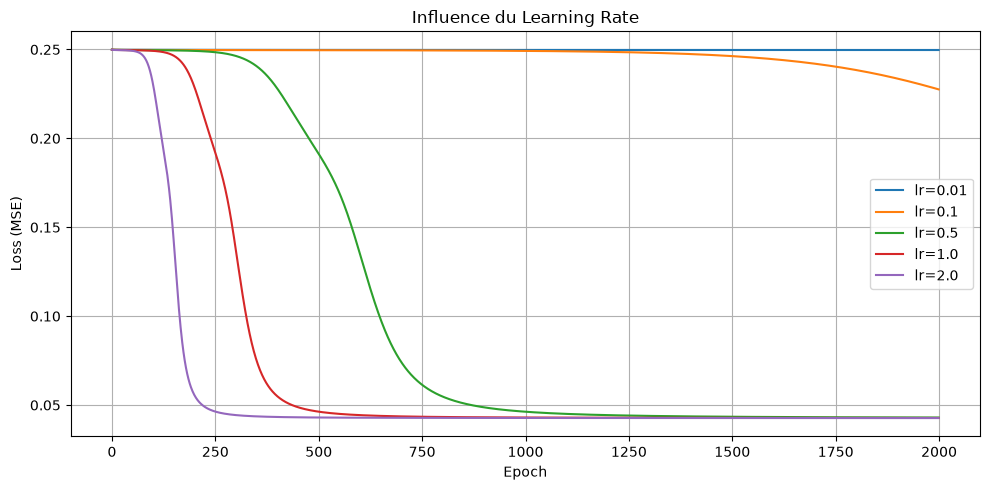

 Influence du nombre de neurones cachés 


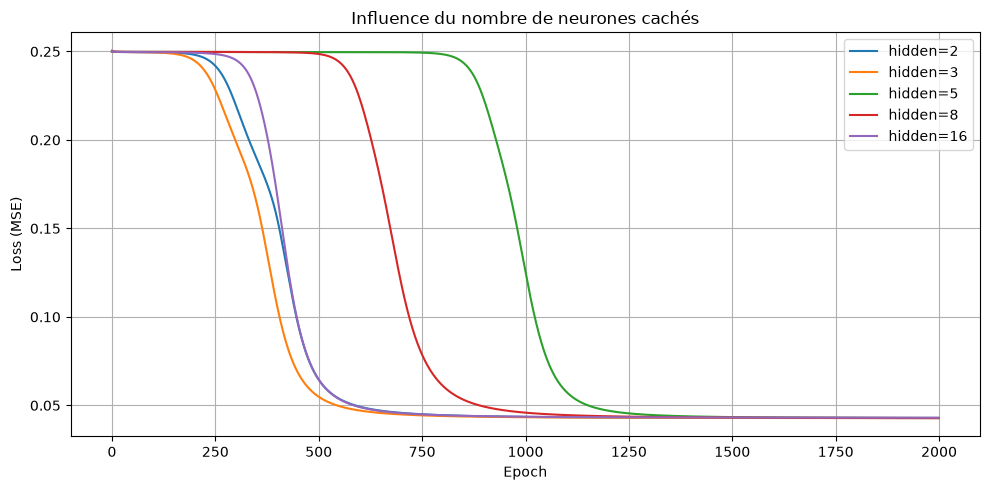

Comparaison neurones cachés sauvegardée.
 Influence de la fonction d'activation 
epoch=   0  loss=0.249841
epoch= 400  loss=0.105510
epoch= 800  loss=0.043975
epoch=1200  loss=0.043035
epoch=1600  loss=0.042853
epoch=   0  loss=0.249998
epoch= 400  loss=0.045929
epoch= 800  loss=0.043320
epoch=1200  loss=0.043094
epoch=1600  loss=0.043039
epoch=   0  loss=0.249990
epoch= 400  loss=0.046788
epoch= 800  loss=0.043455
epoch=1200  loss=0.043194
epoch=1600  loss=0.043130
epoch=   0  loss=0.249803
epoch= 400  loss=0.249771
epoch= 800  loss=0.249766
epoch=1200  loss=0.249759
epoch=1600  loss=0.249749


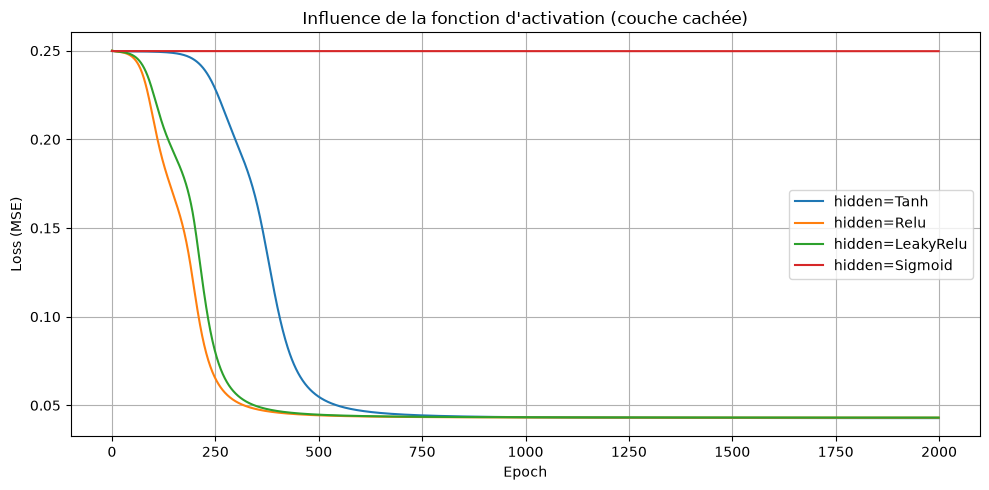

In [49]:
#Evaluation & analyse
print("ANALYSE")

print("\n Influence du Learning Rate ")
learning_rates = [0.01, 0.1, 0.5, 1.0, 2.0]
plt.figure(figsize=(10, 5))

for lr in learning_rates:
    np.random.seed(0)
    W1_ = np.random.randn(2, 3) * 0.1
    b1_ = np.zeros((1, 3))
    W2_ = np.random.randn(3, 1) * 0.1
    b2_ = np.zeros((1, 1))
    _, _, _, _, losses_ = train(
        X, y, W1_, b1_, W2_, b2_,
        lr=lr, epochs=2000,
        f_act_hid=act_hid, f_act_out=act_out,
        df_hid=d_act_hid,  df_out=d_act_out
    )
    plt.plot(losses_, label=f"lr={lr}")

plt.title("Influence du Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/lr_comparison.png", dpi=150)
plt.show()

# ---- Influence du nombre de neurones cachés ----
print(" Influence du nombre de neurones cachés ")
hidden_sizes = [2, 3, 5, 8, 16]
plt.figure(figsize=(10, 5))

for h in hidden_sizes:
    np.random.seed(0)
    W1_ = np.random.randn(2, h) * 0.1
    b1_ = np.zeros((1, h))
    W2_ = np.random.randn(h, 1) * 0.1
    b2_ = np.zeros((1, 1))

    losses_ = []
    for epoch in range(2000):
        yh, (Xc, Z1, A1, Z2, yhc) = forward(
            X, W1_, b1_, W2_, b2_, act_hid, act_out)
        L = mse(yh, y)
        losses_.append(L)
        N = y.shape[0]
        dY  = (2/N)*(yh - y)
        dZ2 = dY * d_act_out(yh)
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)
        dA1 = dZ2 @ W2_.T
        dZ1 = dA1 * d_act_hid(A1)
        dW1 = Xc.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)
        W2_ -= 0.8 * dW2
        b2_ -= 0.8 * db2
        W1_ -= 0.8 * dW1
        b1_ -= 0.8 * db1

    plt.plot(losses_, label=f"hidden={h}")

plt.title("Influence du nombre de neurones cachés")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/hidden_comparison.png", dpi=150)
plt.show()
print("Comparaison neurones cachés sauvegardée.")


# Influence de la fonction d'activation 
print(" Influence de la fonction d'activation ")
act_configs = [
    ("Tanh",       tanh_fn,    d_tanh),
    ("Relu",       relu,       d_relu),
    ("LeakyRelu",  leaky_relu, d_leaky_relu),
    ("Sigmoid",    sigmoid,    d_sigmoid),
]

plt.figure(figsize=(10, 5))

for act_name, act_fn, dact_fn in act_configs:
    np.random.seed(0)
    W1_ = np.random.randn(2, 3) * 0.1
    b1_ = np.zeros((1, 3))
    W2_ = np.random.randn(3, 1) * 0.1
    b2_ = np.zeros((1, 1))
    _, _, _, _, losses_ = train(
        X, y, W1_, b1_, W2_, b2_,
        lr=0.8, epochs=2000,
        f_act_hid=act_fn, f_act_out=sigmoid,
        df_hid=dact_fn,   df_out=d_sigmoid
    )
    plt.plot(losses_, label=f"hidden={act_name}")

plt.title("Influence de la fonction d'activation (couche cachée)")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figures/activation_comparison.png", dpi=150)
plt.show()

